# AgenticRAG with LangGraph

In [32]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq

In [33]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [36]:
# os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
# llm = ChatOpenAI(model="gpt-4o", temperature=0)
# embeddings = OpenAIEmbeddings()

GROQ_API = os.getenv("GROQ_API")

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    groq_api_key=GROQ_API
)

embeddings = HuggingFaceEmbeddings( model_name="sentence-transformers/all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [37]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.4', 'langchain': '1.4.2'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7efb0d7d4410>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7efb0d7d4f50>, model_name='openai/gpt-oss-20b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

# State Definition

In [38]:
class AgentState(TypedDict):
    question: str
    documents: List[Document]
    answer: str
    needs_retrieval: bool

In [39]:
sample_texts = [
    "Python is a high-level programming language used for web development, data science, machine learning, and automation.",
    "Machine learning is a branch of artificial intelligence where computers learn patterns from data and use those patterns to make predictions.",
    "Deep learning is a subset of machine learning that uses neural networks with multiple layers to learn complex patterns from large amounts of data.",
    "Natural language processing (NLP) allows computers to understand, process, and generate human language.",
    "Large language models (LLMs) are deep learning models trained on large amounts of text data to understand and generate natural language.",
    "RAG, or Retrieval-Augmented Generation, combines information retrieval with a language model. It retrieves relevant documents and provides them as context to the LLM.",
    "Embeddings convert text into numerical vectors. Texts with similar meanings generally have vectors that are close to each other in the embedding space.",
    "A vector database stores embeddings and allows applications to search for documents based on semantic similarity.",
    "Chroma is a vector database commonly used in AI and RAG applications to store and retrieve vector embeddings.",
    "LangChain is a framework that provides tools for building applications using large language models, including RAG pipelines and agents.",
    "LangGraph is a framework for building stateful applications and agent workflows using graphs, where nodes perform operations and edges control the flow.",
    "OpenAI provides language models and embedding models that can be accessed through APIs and integrated into applications using libraries such as LangChain.",
    "A chatbot can use RAG to retrieve information from a company's documents before generating an answer, reducing the need for the model to rely only on its training data.",
    "In a typical RAG pipeline, documents are loaded, split into chunks, converted into embeddings, stored in a vector database, retrieved using a user's query, and finally passed to an LLM.",
    "Semantic search finds information based on meaning rather than requiring an exact keyword match. This makes it useful for searching documents using natural language."
]

documents = [Document(page_content=text) for text in sample_texts]
vectorstore = FAISS.from_documents(documents,embeddings)
retriever = vectorstore.as_retriever( search_kwargs={"k": 3})

# Agents function

In [40]:
def decide_retrieval(state: AgentState) -> AgentState:
    question = state["question"]
    retrieval_keywords = ["what", "how", "explain", "describe", "tell_me"]
    needs_retrieval = any(keyword in question.lower() for keyword in retrieval_keywords)
    return {**state, "needs_retrival": needs_retrieval}

In [41]:
def retrival_documents(state: AgentState) -> AgentState:
    question = state["question"]
    documents = retriever.invoke(question)
    return {**state, "documents": documents}

In [42]:
def generate_answer(state: AgentState) -> AgentState:
    question = state["question"]
    documents = state.get("documents", [])

    if documents:
        context = "\n\n".join([doc.page_content for docs in documents])
        prompt = f""" Based on the following context, answer the question: 
        Context:
        {context}
        Question: {question}
        Answer:
        """
    else:
        prompt=f"Answer the following question: {question}"
    response = llm.invoke(prompt)
    answer = response.content
    return { **state, "answer": answer }

# Conditional Logic

In [43]:
def should_retrieve(state: AgentState) -> str:
    if state["needs_retrieval"]:
        return "retrieve"
    else:
        return "generate"

# Build the Graph

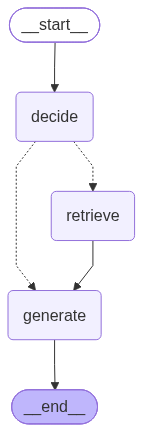

In [44]:
workflow = StateGraph(AgentState)

workflow.add_node("decide", decide_retrieval)
workflow.add_node("retrieve", retrival_documents)
workflow.add_node("generate", generate_answer)

workflow.set_entry_point("decide")
workflow.add_conditional_edges(
    "decide",
    should_retrieve,
    {
        "retrieve": "retrieve",
        "generate": "generate"
    }
)

workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

app = workflow.compile()
app

# Test Agentic System

In [45]:
def ask_question(question: str):
    initial_state = {
        "question" : question,
        "documents": [],
        "answer": "",
        "needs_retrieval": False
    }
    result = app.invoke(initial_state)
    return result

In [46]:
question1 = "what is the chroma"
result1 = ask_question(question1)
result1

{'question': 'what is the chroma',
 'documents': [],
 'answer': '**Chroma** is a term that appears in several fields, most commonly in color science and in music.  \nBelow are the main meanings:\n\n| Field | What “chroma” means | Key points |\n|-------|---------------------|------------|\n| **Color theory / image science** | The *purity* or *saturation* of a color – how much it differs from a neutral gray. | • In the HSV/HSL models, chroma is the distance from the hue axis to the color point. <br>• High chroma = vivid, intense color; low chroma = washed‑out or pastel. |\n| **Digital video / photography** | The color information that is separate from the brightness (luma) component. | • Video signals are often split into luma (Y) and chroma (U/V or Cb/Cr). <br>• Chroma subsampling (e.g., 4:2:0) reduces the resolution of chroma to save bandwidth because the human eye is less sensitive to color detail than to luminance. |\n| **Music** | The *pitch class* of a note, i.e., its position on t

In [49]:
results2 = ask_question(" what is rootkit")
print(f"Question: {results2}")
print(f"Retrieved documents: {len(results2['documents'])}")
print(f"Answer: {results2['answer']}")
print("\n" + "="*50 + "\n")

Question: {'question': ' what is rootkit', 'documents': [], 'answer': '**Rootkit** – a type of malicious software designed to conceal its presence (or that of other malware) on a computer system while granting an attacker privileged (often “root” or administrator) access.\n\n| Feature | What it does |\n|---------|--------------|\n| **Privilege escalation** | Gaining higher-level permissions (root on Unix/Linux, Administrator on Windows). |\n| **Stealth** | Hides files, processes, registry entries, network connections, or even entire operating‑system components from standard system tools and security software. |\n| **Persistence** | Remains on the system across reboots, often by modifying low‑level components (boot loaders, firmware, or kernel modules). |\n| **Remote control** | Allows the attacker to issue commands, exfiltrate data, or install additional malware. |\n\n### How rootkits work\n\n1. **Installation** – via phishing, drive‑by downloads, or exploiting vulnerabilities.  \n2. *